# Estudo de Caso: Preço do Vinho vs. Qualidade Cega - você paga pelo gosto?
### Estudo com SVM (Support Vector Machine)

**Dataset do Kaggle:** https://www.kaggle.com/datasets/sergionefedov/wine-price-vs-blind-qualitydo-you-pay-for-taste

**Questão do estudo:** Será que vinho mais caro é realmente mais gostoso quando a pessoa prova *sem ver o preço* (prova cega)? Ou nós pagamos pela fama do rótulo?

**O que este notebook faz:**

0. Importa as bibliotecas
1. Importa os dados (tabela principal + dict de dados)
2. Explica cada sigla/coluna (o que cada nome significa)
3. Limpa os dados (valores faltantes, duplicados, tipos, outliers)
4. Explora os dados com tabelas e gráficos
5. Treina um modelo **SVM** para prever se um vinho é `overpriced` (caro, mas mediano na prova cega)
6. Avalia o modelo e tira conclusões


## 0. Importando as bibliotecas

Nesta seção, importo as bibliotecas necessárias para o reconhecimento dos dados fornecidos pelos algoritmos de machine learning e para que a representação dos mesmos tenha boa visibilidade.


In [ ]:
import pandas as pd  # ler e mexer em tabelas (DataFrames)
import numpy as np # contas matemáticas rápidas com listas de números
import matplotlib.pyplot as plt  # cria gráficos
import seaborn as sns # estilização dos gráficos, e faz mapa de calor (heatmap)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # train_test_split: divide dados em treino/teste; cross_val_score: testa o modelo em várias partes; StratifiedKKFold: garante que cada fold dividido tenha a messma proporção
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # StandardScaler: padroniza números; OneHotEncoder: transforma texto em números
from sklearn.compose import ColumnTransformer  # ColumnTransformer: aplica transformação diferente em cada tipo de coluna
from sklearn.pipeline import Pipeline # Pipeline: junta transformação + modelo numa sequência só (evita vazamento de dados)
from sklearn.svm import SVC  # SVC: o modelo SVM para classificação (Support Vector Classifier)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # métricas (para avaliação do modelo)

plt.rcParams["figure.figsize"] = (8, 5)  # deixa todos os gráficos com proporção padrão 8x5
sns.set_theme(style="whitegrid")  # deixa o fundo dos gráficos com grade branca para melhor visualização
print("Bibliotecas importadas com sucesso!")  # informa o sucesso da operação


Bibliotecas importadas com sucesso!


## 1. Importando os dados

O dataset tem **2 tabelas (2 arquivos .csv)**:

| Arquivo | O que é |
|---|---|
| `wine_price_vs_blind_quality.csv` | **Tabela principal**: cada linha é um vinho, cada coluna é uma característica dele |
| `data_dictionary.csv` | **Tabela de ajuda (dicionário)**: explica o que cada coluna da tabela principal significa.  |

Vamos ler os dois arquivos.


In [8]:
# Caminho dos arquivos: tento primeiro na mesma pasta do notebook, depois na pasta Downloads
import os  # os: serve para verificar se um arquivo existe no computador

# Determina o path do arquivo do dataset
caminho_csv = "/kaggle/input/datasets/sergionefedov/wine-price-vs-blind-qualitydo-you-pay-for-taste/"
# caminho_csv = ""

print(f"Usando arquivo: {caminho_csv}wine_price_vs_blind_quality.csv")  # mostra qual arquivo foi encontrado

# Lê a tabela principal com o pandas (read_csv = "leia o csv")
df = pd.read_csv(caminho_csv + "wine_price_vs_blind_quality.csv")  # df é o nome que damos para a tabela principal (df = DataFrame)

# Determina o path do caminho do dict
caminho_dict = "/kaggle/input/datasets/sergionefedov/wine-price-vs-blind-qualitydo-you-pay-for-taste/"
# caminho_dict = ""
dicionario = pd.read_csv(caminho_dict + "data_dictionary (2).csv")

# Mostra o tamanho da tabela: (linhas, colunas)
print("\nDimensão da tabela principal (linhas, colunas):", df.shape)

# Mostra as 5 primeiras linhas para espiar os dados
df.head()


Usando arquivo: /kaggle/input/datasets/sergionefedov/wine-price-vs-blind-qualitydo-you-pay-for-taste/wine_price_vs_blind_quality.csv

Dimensão da tabela principal (linhas, colunas): (40000, 19)


,wine_id,region,grape,price,vintage_quality,winemaking_score,region_prestige,region_terroir,scarcity,oak_months,residual_sugar,alcohol,true_quality,blind_rating_expert,blind_rating_novice,blind_rating,sighted_rating,overpriced,value_wine
0,WIN000000,generic_new_world,blend,8.59,7.36,1.88,3.0,5.0,4.81,3,5.0,12.7,79.6,79.0,91.8,85.4,79.3,0,1
1,WIN000001,Mendoza,malbec,49.25,3.76,4.76,5.0,6.0,8.67,18,2.1,14.6,78.8,74.7,84.1,79.4,84.0,1,0
2,WIN000002,Tuscany,sangiovese,8.24,7.02,0.18,7.0,7.0,3.60,6,12.9,12.5,80.8,81.0,86.0,83.5,80.1,0,0
3,WIN000003,Tuscany,sangiovese,18.99,7.50,5.40,7.0,7.0,5.70,10,2.8,13.9,85.5,82.9,87.3,85.1,83.7,0,0
4,WIN000004,Mendoza,sangiovese,57.69,2.86,3.92,5.0,6.0,9.85,17,1.0,15.2,76.0,76.7,72.1,74.4,77.8,1,0


## 2. Dicionário de dados

Nesta seção, explico **o que cada coluna da tabela `wine_price_vs_blind_quality.csv` significa**, usando a tabela `data_dictionary.csv` como fonte.

| Coluna | Tipo | Significado (para iniciantes) |
|---|---|---|
| `wine_id` | string | **Identificador único de cada vinho** (ex: WIN000001). |
| `region` | string | **Região onde o vinho foi feito.** Valores: Bordeaux, Napa, Burgundy, Rioja, Tuscany, Barossa, Mendoza, generic_new_world (genérico do novo mundo) |
| `grape` | string | **Uva principal.** Valores: cab_sauv (cabernet sauvignon), merlot, pinot_noir, tempranillo, malbec, sangiovese, shiraz, blend (mistura) |
| `price` | float | **Preço de venda (em dólares)**. É influenciado por fama e raridade, não só pelo gosto |
| `vintage_quality` | float (0–10) | **QUALIDADE da safra**: o clima daquele ano foi bom para a uva? Nota de 0 a 10 |
| `winemaking_score` | float (0–10) | **QUALIDADE do trabalho do enólogo (quem fez o vinho)**. Nota de 0 a 10 |
| `region_prestige` | float (0–10) | **PRESTÍGIO da região (fama)**. Bordeaux e Burgundy têm fama alta. Isso aumenta o PREÇO |
| `region_terroir` | float (0–10) | **TERROIR: potencial natural da região (solo + clima)**. Isso aumenta a QUALIDADE real |
| `scarcity` | float (0–10) | **ESCASSEZ:** quanto mais raro (poucas garrafas), mais caro. Aumenta o PREÇO |
| `oak_months` | int | **Meses que o vinho ficou no barril de carvalho** (dá sabor de madeira/baunilha) |
| `residual_sugar` | float | **Açúcar que sobrou no vinho (g/L)**. Quanto maior, mais docinho |
| `alcohol` | float | **Teor alcoólico em %** (ex: 13.5 significa 13,5% de álcool) |
| `true_quality` | float (0–100) | **Qualidade REAL escondida** (ninguém vê): calculada a partir de terroir + safra + enólogo. NÃO depende do preço |
| `blind_rating_expert` | float | **Nota que ESPECIALISTAS deram provando SEM ver o preço** (prova cega) |
| `blind_rating_novice` | float | **Nota que INICIANTES deram provando SEM ver o preço** (prova cega) |
| `blind_rating` | float | **Média** das provas cegas (junta especialista + iniciante). É a nota "honesta", sem efeito do preço |
| `sighted_rating` | float | Nota quando a pessoa **VÊ O PREÇO antes de provar**. (opinião com a interferência do efeito placebo: "se é caro, deve ser bom") |
| `overpriced` | int (0 ou 1) | **ALVO 1 (classificação):** 1 = vinho caro, mas mediano na prova cega (você paga pelo rótulo); 0 = preço justo |
| `value_wine` | int (0 ou 1) | **ALVO 2:** 1 = vinho barato, mas excelente na prova cega (achado, custo-benefício); 0 = não é achado |

Segue o dicionário na tela, para confirmação:


In [9]:
# Exibe a tabela com column, type, description
print(dicionario)

                 column    type  \
0               wine_id  string   
1                region  string   
2                 grape  string   
3                 price   float   
4       vintage_quality   float   
5      winemaking_score   float   
6       region_prestige   float   
7        region_terroir   float   
8              scarcity   float   
9            oak_months     int   
10       residual_sugar   float   
11              alcohol   float   
12         true_quality   float   
13  blind_rating_expert   float   
14  blind_rating_novice   float   
15         blind_rating   float   
16       sighted_rating   float   
17           overpriced     int   
18           value_wine     int   

                                          description  
0                                      Unique wine id  
1   Wine region (Bordeaux, Napa, Burgundy, Rioja, ...  
2                               Primary grape variety  
3   Retail price (USD) — driven mostly by region p...  
4          QUALITY:

## 3. Limpeza dos dados
Já nesta seção, é feita a limpeza dos dados (verificação de duplicatas de linhas, dados faltantes, tipo incorreto ou outliers)

In [10]:
# Retorno a quantidade de linhas e colunas do dataframe
print(f"Formato: {df.shape}\n")

# info() retorna nome da coluna, quantidade de valores não-nulos e o tipo (object=texto, float64=número com vírgula, int64=inteiro)
print(df.info())


Formato: (40000, 19)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   wine_id              40000 non-null  object 
 1   region               40000 non-null  object 
 2   grape                40000 non-null  object 
 3   price                40000 non-null  float64
 4   vintage_quality      40000 non-null  float64
 5   winemaking_score     40000 non-null  float64
 6   region_prestige      40000 non-null  float64
 7   region_terroir       40000 non-null  float64
 8   scarcity             40000 non-null  float64
 9   oak_months           40000 non-null  int64  
 10  residual_sugar       40000 non-null  float64
 11  alcohol              40000 non-null  float64
 12  true_quality         40000 non-null  float64
 13  blind_rating_expert  40000 non-null  float64
 14  blind_rating_novice  40000 non-null  float64
 15  blind_rating  

In [11]:
# Retorno a quantidade de células vazias por coluna
print("Valores faltantes por coluna:")  # isnull() marca True onde está vazio; sum() conta quantos por coluna
print(df.isnull().sum())

# Retorno a quantidade de linhas duplicadas, para verificar se algum vinho é repetido dentre as linhas
print("\nLinhas duplicadas:", df.duplicated().sum())  # duplicated() acha linhas idênticas; sum() conta


Valores faltantes por coluna:
wine_id                0
region                 0
grape                  0
price                  0
vintage_quality        0
winemaking_score       0
region_prestige        0
region_terroir         0
scarcity               0
oak_months             0
residual_sugar         0
alcohol                0
true_quality           0
blind_rating_expert    0
blind_rating_novice    0
blind_rating           0
sighted_rating         0
overpriced             0
value_wine             0
dtype: int64

Linhas duplicadas: 0


In [12]:
# Retorno dados básicos, como quantidade (count), mean (média), std (standard deviation, ou desvio padrão),
# valor mínimo (min), 25%, 50% (mediana), 75%, e o valor máximo
df.describe()


,price,vintage_quality,winemaking_score,region_prestige,region_terroir,scarcity,oak_months,residual_sugar,alcohol,true_quality,blind_rating_expert,blind_rating_novice,blind_rating,sighted_rating,overpriced,value_wine
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,33.472059,5.012889,4.995309,6.328175,6.359500,6.774724,11.994975,3.010625,13.499825,81.997213,82.016500,82.005633,82.011462,82.038507,0.165175,0.104725
std,30.624976,1.982137,1.985396,2.182200,0.932701,2.187676,8.416378,2.457241,1.203876,4.942299,5.434911,4.806245,4.556418,5.495620,0.371343,0.306203
min,4.000000,0.000000,0.000000,3.000000,5.000000,0.000000,0.000000,0.000000,8.500000,70.000000,70.000000,70.000000,70.000000,70.000000,0.000000,0.000000
25%,14.070000,3.670000,3.630000,5.000000,6.000000,5.270000,6.000000,1.200000,12.700000,78.600000,78.200000,78.700000,78.800000,78.200000,0.000000,0.000000
50%,24.490000,5.000000,4.990000,6.000000,6.000000,6.870000,10.000000,2.400000,13.500000,82.000000,82.000000,82.000000,82.000000,82.000000,0.000000,0.000000
75%,42.392500,6.370000,6.340000,8.000000,7.000000,8.500000,16.000000,4.100000,14.300000,85.400000,85.700000,85.300000,85.200000,85.800000,0.000000,0.000000
max,636.080000,10.000000,10.000000,9.000000,8.000000,10.000000,48.000000,22.900000,17.000000,100.000000,100.000000,100.000000,98.400000,100.000000,1.000000,1.000000


In [13]:
# Retorno a contagem de vinhos por região
print("Contagem por REGIÃO:")  # value_counts() conta quantas vezes cada valor aparece
print(df["region"].value_counts())

# Retorno a contagem de vinhos por uva, mostrando qual uva é mais comum no dataset
print("\nContagem por UVA:")
print(df["grape"].value_counts())

Contagem por REGIÃO:
region
generic_new_world    8799
Bordeaux             5569
Napa                 5279
Rioja                4360
Tuscany              4343
Mendoza              4066
Burgundy             3994
Barossa              3590
Name: count, dtype: int64

Contagem por UVA:
grape
cab_sauv       7138
blend          6697
merlot         4812
pinot_noir     4780
tempranillo    4481
malbec         4091
sangiovese     4027
shiraz         3974
Name: count, dtype: int64


In [14]:
# Definindo quantos vinhos são overpriced (acima do preço)
print("overpriced (1 = caro e mediano):")  # 0 = preço justo, 1 = pagou pelo rótulo
print(df["overpriced"].value_counts())

# Definindo quantos vinhos são custo-benefício (barato e excelente)
print("\nvalue_wine (1 = barato e ótimo):")  # 0 = não é achado, 1 = achado
print(df["value_wine"].value_counts())

# Retorno também em porcentagem (normalize=True transforma em fração; *100 vira %)
print("\nPorcentagem overpriced:")
print(df["overpriced"].value_counts(normalize=True) * 100)


overpriced (1 = caro e mediano):
overpriced
0    33393
1     6607
Name: count, dtype: int64

value_wine (1 = barato e ótimo):
value_wine
0    35811
1     4189
Name: count, dtype: int64

Porcentagem overpriced:
overpriced
0    83.4825
1    16.5175
Name: proportion, dtype: float64


In [15]:
# Buscando outliers (valores totalmente fora da média)
print("Maiores preços:")  # nlargest(5, 'price') pega os 5 maiores preços
print(df.nlargest(5, "price")[["wine_id", "region", "price", "blind_rating", "sighted_rating"]])

# Retorno apenas os dados descritos da coluna "price"
print("\nResumo do preço:")
print(df["price"].describe())


Maiores preços:
         wine_id    region   price  blind_rating  sighted_rating
26583  WIN026583  Bordeaux  636.08          77.0            87.2
34563  WIN034563  Burgundy  454.23          81.1            85.2
7586   WIN007586  Bordeaux  453.90          86.6            94.2
21677  WIN021677      Napa  451.76          78.2            87.3
34828  WIN034828  Burgundy  416.65          84.2            91.8

Resumo do preço:
count    40000.000000
mean        33.472059
std         30.624976
min          4.000000
25%         14.070000
50%         24.490000
75%         42.392500
max        636.080000
Name: price, dtype: float64


É analisado que a tabela possui **40.000 vinhos**, **19 colunas**, **sem valores faltantes** e **sem duplicados**.

O preço vai de 4 a 636 dólares, os vinhos mais caros são outliers, e as classes são desbalanceadas: apenas ~16% são `overpriced` e ~10% são `value_wine`.


## 4. Exploração dos dados (EDA) com gráficos

Nesta seção é feita a Análise Exploratória de Dados, onde são apresentados gráficos relatando os dados relevantes para a pesquisa.


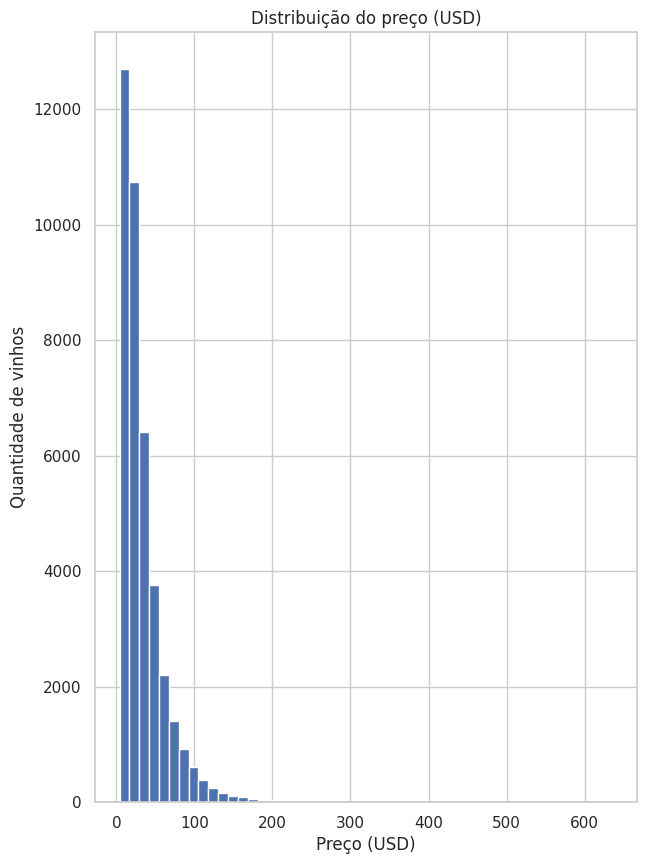

In [16]:
# Crio um histograma do preço, para entender se a maioria dos vinhos é barato ou caro
plt.figure(figsize=(7,10))  # cria uma figura nova
plt.hist(df["price"], bins=50)  # o comando '.hist()' divide os preços em 50 faixas e conta quantos vinhos caem em cada faixa
plt.title("Distribuição do preço (USD)")  # título do gráfico
plt.xlabel("Preço (USD)")  # nome do eixo x
plt.ylabel("Quantidade de vinhos")  # nome do eixo y
plt.show()  # retorna o gráfico


Com a visualização do histograma, é perceptível que há uma quantidade consideravelmente maior de vinhos baratos do que caros na análise.

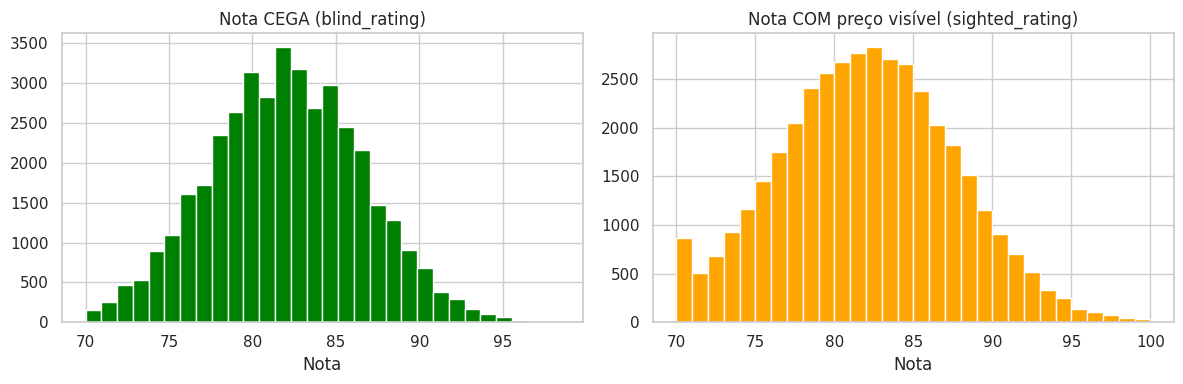

In [17]:
# Crio histogramas que retornam a comparação das notas dos os testadores que viram o preço com as dos testadores que não viram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # cria 2 gráficos lado a lado

# Primeiro, criando o histograma dos testadores que não viram o preço
axes[0].hist(df["blind_rating"], bins=30, color="green") # separado em 30 faixas
axes[0].set_title("Nota CEGA (blind_rating)")  # título
axes[0].set_xlabel("Nota")  # título do eixo x

# Depois, criando o histograma dos testadores que viram o preço
axes[1].hist(df["sighted_rating"], bins=30, color="orange")  # também separado em 30 faixas
axes[1].set_title("Nota COM preço visível (sighted_rating)")  # título
axes[1].set_xlabel("Nota")  # título eixo x

plt.tight_layout()  # ajusta o espaço para os gráficos não se sobreporem
plt.show() # retorna os gráficos


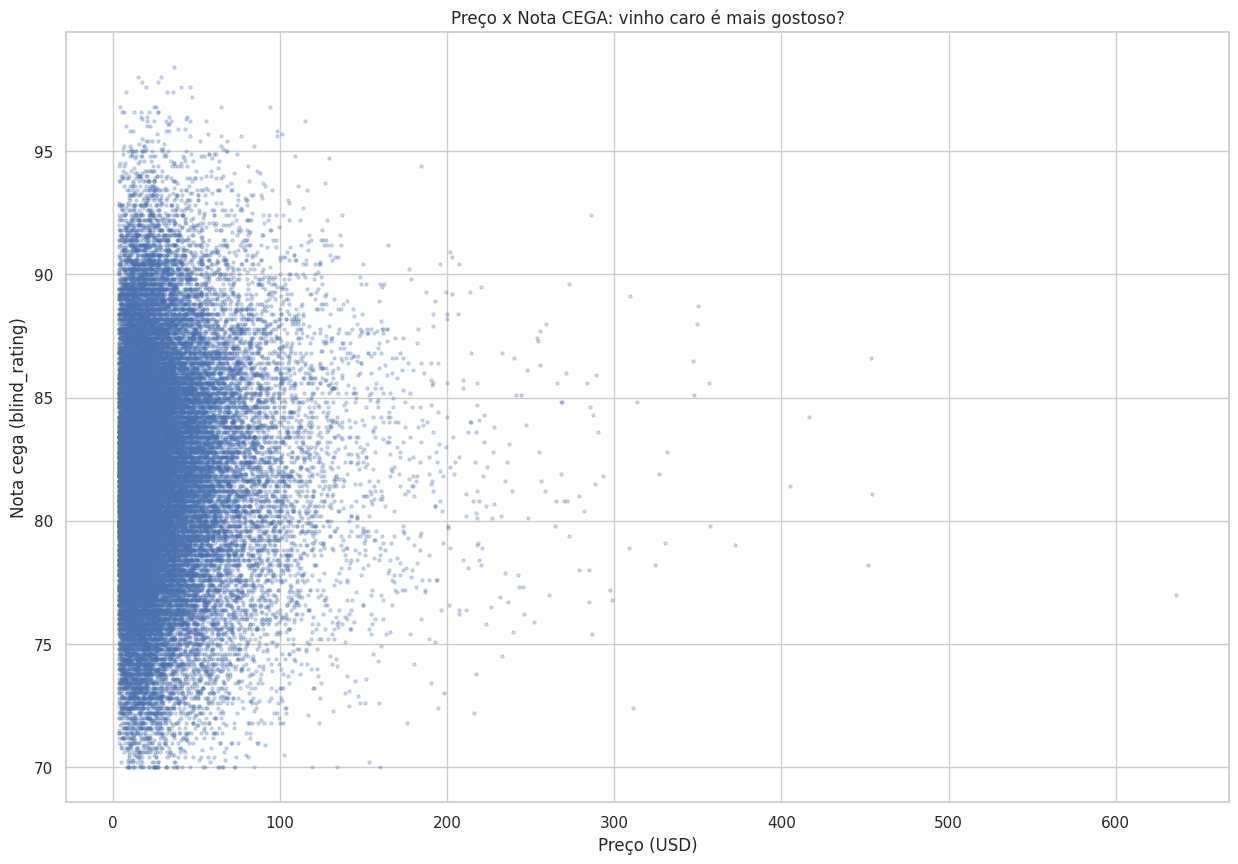

Correlação preço x nota CEGA: 0.03509190773322331
Correlação preço x nota COM preço visível: 0.43158737364468003


In [18]:
# Gráfico de dispersão, que responderá se o preço prevê corretamente o gosto (dispersão do com preço x sem preço)
plt.figure(figsize=(15,10))  # nova figura
plt.scatter(df["price"], df["blind_rating"], alpha=0.25, s=5)  # scatter = pontos; alpha=0.25 deixa transparente
plt.title("Preço x Nota CEGA: vinho caro é mais gostoso?")  # título
plt.xlabel("Preço (USD)")  # eixo x = preço
plt.ylabel("Nota cega (blind_rating)")  # eixo y = nota honesta
plt.show() # retorna o gráfico dde dispersão

# Calcula a correlação (de -1 a 1): -1 = inversamente proporcional, 0 = sem relação, 1 = diretamente proporcional
print("Correlação preço x nota CEGA:", df["price"].corr(df["blind_rating"]))  # o comando '.corr()' mede a força da relação
print("Correlação preço x nota COM preço visível:", df["price"].corr(df["sighted_rating"]))


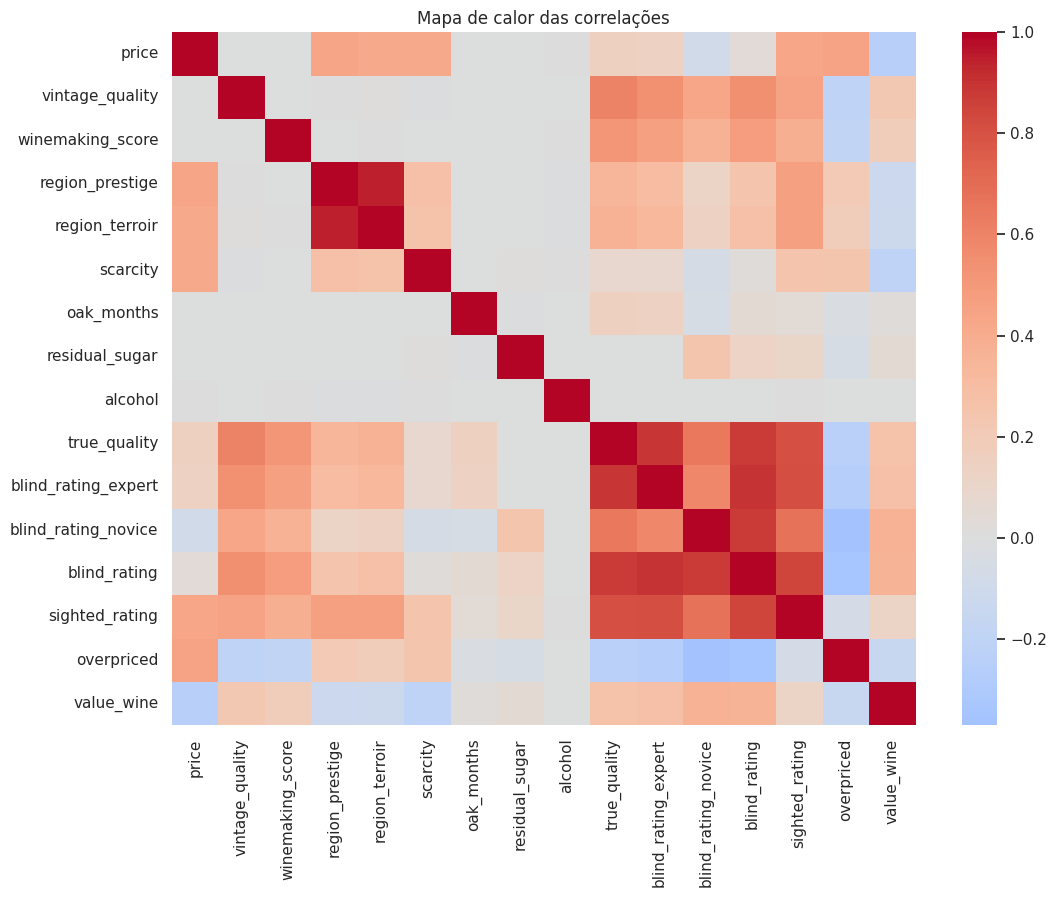

Correlação de cada coluna com blind_rating:
overpriced            -0.346980
alcohol                0.002273
scarcity               0.017916
price                  0.035092
oak_months             0.055308
residual_sugar         0.130582
region_prestige        0.252082
region_terroir         0.273464
value_wine             0.361082
winemaking_score       0.475774
vintage_quality        0.552599
sighted_rating         0.841815
blind_rating_novice    0.874348
true_quality           0.879184
blind_rating_expert    0.903242
blind_rating           1.000000
Name: blind_rating, dtype: float64


In [19]:
# Mapa de calor (heatmap) das correlações, para verificar o que é relacionado com o que e em qual nível.
colunas_numericas = df.select_dtypes(include="number").columns  # o comando '.select_dtypes' pega só as colunas de números
correlacao = df[colunas_numericas].corr()  # o comando '.corr()' calcula a correlação de cada par de colunas

plt.figure(figsize=(12, 9))  # aumento da figura
sns.heatmap(correlacao, annot=False, cmap="coolwarm", center=0)  # azul = correlação negativa, vermelho = correlação positiva
plt.title("Mapa de calor das correlações")  # título
plt.show()

# Mostra as correlações ordenadas com a nota cega (do menor para o maior)
print("Correlação de cada coluna com blind_rating:")
print(correlacao["blind_rating"].sort_values())


Com o heatmap passado, é compreendido que, **em relação aos dados da avaliação cega**:
- A correlação dos dados dos vinhos caros, níveis de álcool e escassez é **baixíssima**
- Já a correlação dos dados da qualidade real dos vinhos, é **altíssima** *(até um pouco maior do que a correlação das avaliações cegas de novatos)*

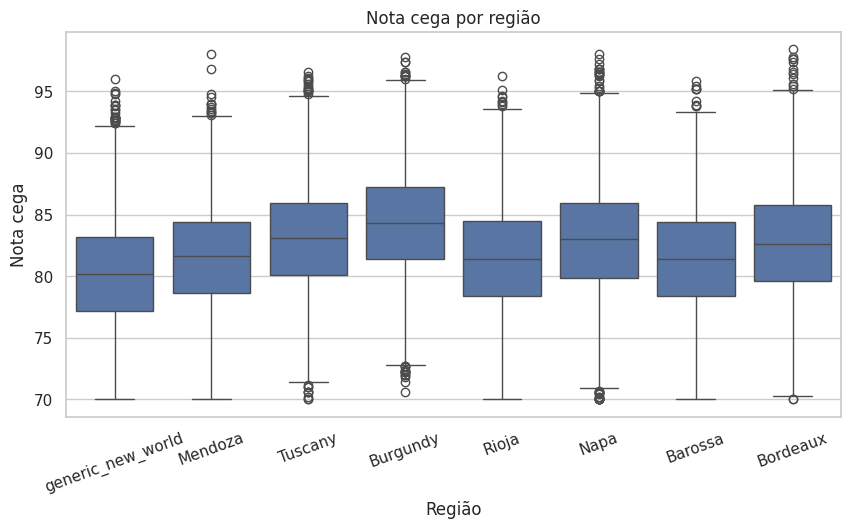

Preço médio por região:
region
Bordeaux             53.088959
Burgundy             52.886748
Napa                 42.790205
Tuscany              34.940449
Barossa              28.768758
Rioja                27.750468
Mendoza              23.286904
generic_new_world    15.389021
Name: price, dtype: float64


In [20]:
# Criando um boxplot, para verificar se a nota cega se altera dependendo da região
plt.figure(figsize=(10, 5))  # figura mais larga (são 8 regiões)
sns.boxplot(data=df, x="region", y="blind_rating")  # boxplot mostra mediana, quartis e outliers por grupo
plt.title("Nota cega por região")  # título
plt.xlabel("Região")  # eixo x
plt.ylabel("Nota cega")  # eixo y
plt.xticks(rotation=20)  # gira os nomes das regiões para não se sobreporem
plt.show()

# Retornando o preço médio por região, para verificar qual região cobra mais caro
print("Preço médio por região:")
# o comando '.groupby('region')' agrupa por região; '['price'].mean()' tira a média do preço; '.sort_values()' ordena do maior para o menor
print(df.groupby("region")["price"].mean().sort_values(ascending=False))


De acordo com o boxplot retornado, é perceptível que há consideravelmente um **número maior** de outliers de **notas cegas altas** do que baixas, com o preço médio variando de **~15 USD** para até **~53 USD** generalizando pelas regiões.

                price  blind_rating  sighted_rating
overpriced                                         
0           27.428393     82.714692       82.189782
1           64.017866     78.457212       81.273937


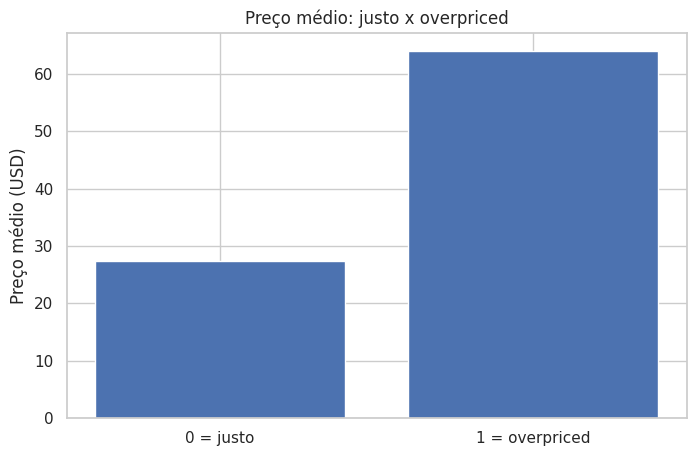

In [21]:
# Agora, com um gráfico de barras simples, é comparada a média do preço do vinho superfaturado do justo, para verificar se o rótulo engana de fato
# Agrupa pela coluna overpriced (0 = justo, 1 = caro e mediano), e tira a média de preço, nota cega e nota com preço
print(df.groupby("overpriced")[["price", "blind_rating", "sighted_rating"]].mean())

# Criação do gráfico de barras, comparando os preços
medias = df.groupby("overpriced")["price"].mean()  # média de preço por grupo
plt.figure()  # nova figura
plt.bar(["0 = justo", "1 = overpriced"], medias.values)  # o comando '.bar()' faz um gráfico de barras
plt.title("Preço médio: justo x overpriced")  # título
plt.ylabel("Preço médio (USD)")  # ttítulo do eixo y
plt.show() # é retornado o gráfico


De acordo com os dados analisados na exploração, **o preço quase NÃO tem relação com a nota cega**, com a correlação de **apenas `~0,03`** (tende a zero), mas **tem relação média com a nota quando o preço aparece**, com a correlação de **`~0,43`**. Ou seja: **ver o preço infla a nota** (efeito placebo).

O mapa de calor mostra que `blind_rating` **anda junto** com `true_quality` (qualidade real) **e com as notas de especialista/novato**, enquanto `price` **anda junto** com `region_prestige` (fama) e `scarcity` (raridade).

Então, respondendo a pergunta que levou à pesquisa: *do you pay for taste?* (você paga pelo gosto?): **Não, você paga pelo rótulo!**


## 5. Preparando os dados para o SVM

Nesta seção, os dados são preparados para o SVM (Support Vector Machine), e neste processo, os dados são separados em características (texto) e rótulos (numérico). O SVM vai criar uma linha de separação entre os dados dos pontos "overpriced" e "justos", com a maior margem possível, e com o kernel sendo o `rbf`, a linha pode ser curva para melhor se adaptar aos dados.

O objetivo é prever a coluna `overpriced` (0 = justo, 1 = caro e mediano), e é uma classificação binária (só 2 respostas possíveis).

As funções são:
- Números (`price`, `alcohol`...) são padronizados com `StandardScaler` (média 0, desvio 1)
- Textos (`region`, `grape`) são transformados em números com `OneHotEncoder` (cria colunas 0/1)

In [22]:
# 5.1 Separando X (características = pergunta) e y (resposta = overpriced)
# Primeiro, o X (características) é separado do y (rótulos)
colunas_num = ["price", "vintage_quality", "winemaking_score", "region_prestige",
               "region_terroir", "scarcity", "oak_months", "residual_sugar",
               "alcohol", "true_quality", "blind_rating_expert",
               "blind_rating_novice", "blind_rating", "sighted_rating"]  # todas as numéricas úteis
colunas_cat = ["region", "grape"]  # as duas linhas de texto

X = df[colunas_num + colunas_cat]  # X = tudo que o modelo pode olhar
y = df["overpriced"]  # y = a resposta a ser prevista (0 ou 1)

print("Tamanho de X:", X.shape)  # mostra quantas linhas e colunas o modelo vai usar
print("Tamanho de y:", y.shape)  # y tem o mesmo número de linhas
print("\nProporção das classes:")  # retorna o desbalanceamento
print(y.value_counts(normalize=True))


Tamanho de X: (40000, 16)
Tamanho de y: (40000,)

Proporção das classes:
overpriced
0    0.834825
1    0.165175
Name: proportion, dtype: float64


In [23]:
# Para não sobrecarregar o SVM usando todas as amostras, vou utilizar 1/5 da quantidade das amostras (8000 vinhos)
df_amostra = df.sample(n=len(df.values)//5, random_state=42, replace=False)  # o comando '.sample()' sorteia 8000 linhas; e 'random_state=42' fixa o sorteio para repetir igualmente

X = df_amostra[colunas_num + colunas_cat]  # refaz X só com a amostra
y = df_amostra["overpriced"]  # refaz y só com a amostra
print("Amostra para o SVM:", X.shape)  # confirma o novo tamanho

# Agora, dividindo os dados de treino (80%) e os dados de teste (20%)
# 'train_test_split' separa: o modelo aprende no treino, e é avaliado no teste (que ele não tem os dados, para não enviesar)
# 'stratify=y' mantém a proporção de overpriced nos dois grupos; 'random_state=42' mantém o sorteio repetível
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Retorno o tamanho do treino e do teste
print("Treino:", X_train.shape)  # 6400 linhas para aprender
print("Teste:", X_test.shape)  # 1600 linhas para avaliar


Amostra para o SVM: (8000, 16)
Treino: (6400, 16)
Teste: (1600, 16)


In [24]:
# Pré-processando os dados e aplicando o modelo SVM dentro de um Pipeline
preprocessamento = ColumnTransformer( # 'ColumnTransformer' aplica 'StandardScaler' nos números e 'OneHotEncoder' nos textos
    transformers=[
        ("num", StandardScaler(), colunas_num),  # padroniza as colunas numéricas
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_cat),  # transforma region/grape em colunas 0/1
    ]
)

# Pipeline: primeiro preprocessa, depois treina o SVM (tudo de uma vez, para que não haja vazamento de dados)
pipelines_dict = {
    'linear': Pipeline(steps=[
        ("prep", preprocessamento),  # preparando os dados
        ("svm", SVC(kernel="linear", C=0.1, random_state=42)),  # aplicando o SVM
    ]),
    'rbf': Pipeline(steps=[
        ("prep", preprocessamento),  # preparando os dados
        ("svm", SVC(kernel="rbf", C=10.0, gamma=0.04, random_state=42)),  # aplicando o SVM
        # 'kernel'= rbf (fronteira curva); 'C'=10.0 (equilíbrio entre acertar tudo e generalizar);
    ]),
    'poly': Pipeline(steps=[
        ("prep", preprocessamento),  # preparando os dados
        ("svm", SVC(kernel="poly", C=0.005, gamma=0.85, random_state=42)),  # aplicando o SVM
    ]),
    'sigmoid': Pipeline(steps=[
        ("prep", preprocessamento),  # preparando os dados
        ("svm", SVC(kernel="sigmoid", C=0.6, gamma=0.004, random_state=42)),  # aplicando o SVM
    ]),
}

## 6. Treinando e avaliando o SVM


In [25]:
# Agora, treinando os dados (o comando '.fit()' treina o modelo com os dados de treino,
# fazendo o algoritmo aprender a melhor forma de manter a linha de separação)
for modelo_svm in pipelines_dict.values():
    modelo_svm.fit(X_train, y_train)
print("Modelos treinados!")

# Fazendo um teste com o modelo treinado, o comando '.predict() retorna 0 ou 1 para cada vinho do testte
y_pred_dict = {
    key: value.predict(X_test) for key, value in pipelines_dict.items()
}

Modelos treinados!


In [26]:
# Relatório de precision (acurácia dos testes de overpriced), recall (acurácia dos overpriced reais) e f1 (média do 'precision' e do 'recall')
for modelo_svm, y_pred in y_pred_dict.items():
    print("=====", modelo_svm, "=====")
    print(classification_report(y_test, y_pred, target_names=["0 = justo", "1 = overpriced"], digits=4).replace("\n\n", "\n")[:-1])

===== linear =====
                precision    recall  f1-score   support
     0 = justo     0.9144    0.9632    0.9382      1331
1 = overpriced     0.7525    0.5539    0.6381       269
      accuracy                         0.8944      1600
     macro avg     0.8335    0.7585    0.7881      1600
  weighted avg     0.8872    0.8944    0.8877      1600
===== rbf =====
                precision    recall  f1-score   support
     0 = justo     0.9798    0.9857    0.9828      1331
1 = overpriced     0.9272    0.8996    0.9132       269
      accuracy                         0.9712      1600
     macro avg     0.9535    0.9427    0.9480      1600
  weighted avg     0.9710    0.9712    0.9711      1600
===== poly =====
                precision    recall  f1-score   support
     0 = justo     0.9652    0.9790    0.9720      1331
1 = overpriced     0.8880    0.8253    0.8555       269
      accuracy                         0.9531      1600
     macro avg     0.9266    0.9021    0.9138      1

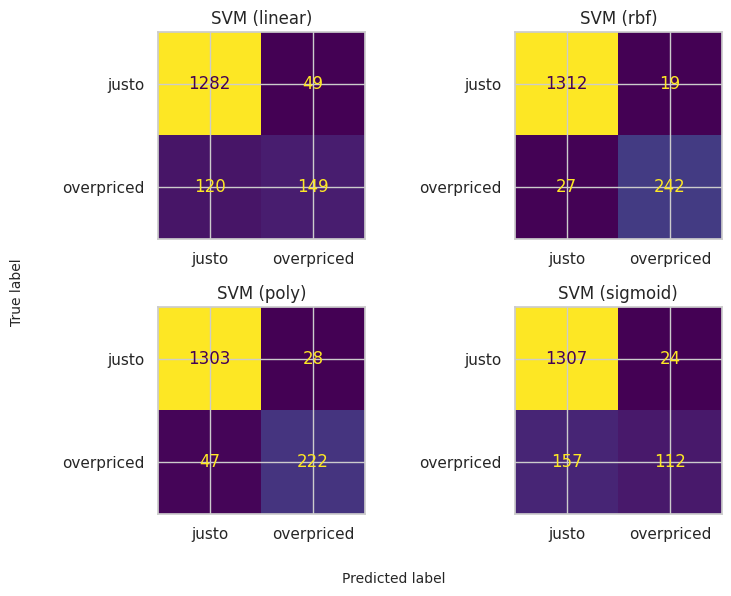

In [27]:
# Criando a matriz de confusão, para determinar os acertos e os erros do modelo treinado
# Linhas = valor real, Colunas = valor previsto
# Diagonal = acertos, fora da diagonal = erros

# Criação dos gráficos das matrizes de confusão em uma única figura
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
matrizes = [confusion_matrix(y_test, matriz) for matriz in y_pred_dict.values()]
kernels = [modelo_svm for modelo_svm in y_pred_dict.keys()]

for (y_idx, x_idx), matriz, kernel in zip(np.ndindex(axes.shape), matrizes, kernels):
    ax = axes[y_idx, x_idx]
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["justo", "overpriced"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"SVM ({kernel})")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel(f"Predicted label ({len(X_test)})", size=10)
fig.supylabel(f"True label ({len(X_test)})", size=10)
fig.tight_layout()
plt.show()

In [33]:
# Agora, fazendo a validação cruzada, o modelo é testado em 5 partes diferentes (folds), para termos certeza que nenhum teste foi extremo
# o comando 'StratifiedKFold(n_splits=5)' divide em 5 pedaços mantendo a proporção das classes; cross_val_score treina e avalia 5 vezes
partes = 5
cv = StratifiedKFold(n_splits=partes, shuffle=True, random_state=42)  # prepara as 5 divisões

cv_dict = {
    modelo_svm: cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy") for modelo_svm, pipeline in pipelines_dict.items()
}

acuracias_cv = [acuracias.mean() for acuracias in list(cv_dict.values())]

print(f"Acurácias das {partes} partes de cada SVM:\n")
for modelo_svm, score in cv_dict.items():
    print("=====", modelo_svm, "=====") # mostra cada divisão
    print(score) # mostra cada divisão
    print(f"Média: {score.mean():.4f} | Desvio padrão: {score.std():.4f}\n") # retorna a média e desvio padrão

Acurácias das 5 partes de cada SVM:

===== linear =====
[0.894375 0.895    0.89375  0.898125 0.895625]
Média: 0.8954 | Desvio padrão: 0.0015

===== rbf =====
[0.969375 0.97     0.9675   0.973125 0.97875 ]
Média: 0.9718 | Desvio padrão: 0.0039

===== poly =====
[0.955   0.955   0.95125 0.95125 0.955  ]
Média: 0.9535 | Desvio padrão: 0.0018

===== sigmoid =====
[0.87875  0.886875 0.878125 0.888125 0.88625 ]
Média: 0.8836 | Desvio padrão: 0.0043



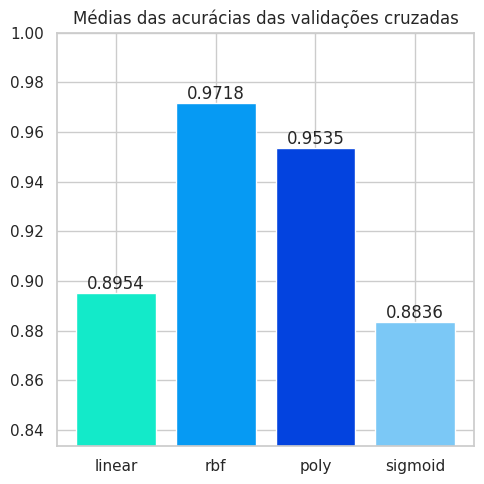

In [29]:
plt.figure(figsize=(5,5))
ax = plt.bar(
    list(cv_dict.keys()),
    acuracias_cv,
    color=["xkcd:aqua", "xkcd:azure", "xkcd:blue", "xkcd:lightblue"],
)
plt.bar_label(ax, [f"{acuracia:.4f}" for acuracia in acuracias_cv])
plt.ylim(min(acuracias_cv) - 0.05, 1.0)
plt.title("Médias das acurácias das validações cruzadas")
plt.tight_layout()
plt.show()

## 7. Conclusão - Você paga pelo gosto?

**O que os dados gráficos mostraram:**
- **Preço x nota cega**: correlação quase zero -> vinho caro NÃO é necessariamente mais gostoso, de acordo com as provas cegas.
- **Preço x nota com preço visível**: correlação ~0,43 -> quando vemos o preço, damos nota maior (placebo do rótulo).
- **Preço anda junto** com `region_prestige` (fama) e `scarcity` (raridade)
- **Nota cega anda junto** com `true_quality` (qualidade real).

**Os dados que o SVM mostrou:** o modelo aprende a separar vinhos `overpriced` (caros e medianos) com boa acurácia, usando principalmente **preço, prestígio, escassez** e a **diferença entre** `sighted_rating` e `blind_rating`. Ou seja, é possível para *prever* quando se paga pelo rótulo.

**Resposta final:** Na prova cega, **não se paga pelo gosto**, mas sim pela **fama e raridade**, e o SVM ajuda a detectar esses casos.

**Limitações:** Utilizei apenas 1/5 das amostras (8000 linhas) pois o SVM com kernel RBF é relativamente lento; não fiz busca de hiperparâmetros (`C`, `gamma`); e `blind_rating`/`sighted_rating` facilitam muito a previsão. Um próximo passo seria prever `overpriced` SEM usar as notas, só com preço + região + uva + química.
